# Metodologia de Dados — Projeto 3W Petrobras
## Pipeline RAW → BRONZE → SILVER → GOLD e Treinamento ML

**Autor:** Alan Pinheiro da Silva  
**Dataset:** [3W Dataset — Petrobras](https://github.com/petrobras/3W)  
**Objetivo:** Documentar e visualizar cada etapa do pipeline de dados, desde a ingestão bruta até o treinamento dos modelos de classificação de eventos em poços offshore.

---

### Estrutura do Notebook

| # | Seção | Conteúdo |
|---|-------|----------|
| 1 | Visão Geral | Dataset 3W, sensores, poços, arquitetura de camadas |
| 2 | Camada RAW | Estrutura dos arquivos, leitura, schema |
| 3 | Análise Estatística | Max, min, média, std, percentis por sensor |
| 4 | Pressão e Temperatura | Análise específica dos 8 sensores |
| 5 | Camada BRONZE | Tipagem, metadados, validação de schema |
| 6 | Camada SILVER | Limpeza, ranges físicos, forward fill |
| 7 | Teoria de Scaling | Z-score vs MinMax vs Robust — fundamentos |
| 8 | Normalização Z-score | Aplicação correta (fit só no treino) |
| 9 | Feature Engineering | Rolling stats, lags, deltas |
| 10 | Camada GOLD | Splits temporais 70/15/15, dataset ML-ready |
| 11 | Treinamento ML | Distribuição de treino, desbalanceamento, class_weight |

## Célula 1 — Configuração do Ambiente

Instalação das dependências e configuração de caminhos. O notebook detecta automaticamente
se os dados reais do projeto estão disponíveis; caso contrário, gera dados sintéticos
fiéis à estrutura do dataset 3W para fins ilustrativos.

In [1]:
import os
import sys
import warnings
import subprocess
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Instala dependências ausentes
_deps = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'pyarrow', 'scikit-learn']
for dep in _deps:
    try:
        __import__(dep.replace('-', '_'))
    except ImportError:
        print(f'Instalando {dep}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', dep, '-q'], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.facecolor': 'white',
})

# Localiza diretório raiz do projeto
_CANDIDATES = [
    r'D:\Alan\Alan\Pos GRADUAÇÂO USP\eEDB-007 - Trabalho de Conclusão\projeto-3w-aws',
    r'C:\projeto-3w-aws',
    Path.cwd().parent,
    Path.cwd(),
]
PROJECT_DIR = None
for c in _CANDIDATES:
    p = Path(c)
    if (p / 'data' / 'gold').exists():
        PROJECT_DIR = p
        break

if PROJECT_DIR:
    print(f'Projeto encontrado: {PROJECT_DIR}')
    GOLD_DIR      = PROJECT_DIR / 'data' / 'gold'
    BRONZE_DIR    = PROJECT_DIR / 'data' / 'bronze'
    SILVER_DIR    = PROJECT_DIR / 'data' / 'silver'
    PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
    USE_REAL_DATA = True
else:
    print('Projeto nao encontrado — usando dados sintéticos para ilustração.')
    USE_REAL_DATA = False

print(f'Modo: {"DADOS REAIS" if USE_REAL_DATA else "DADOS SINTÉTICOS"}')

Instalando scikit-learn...
Projeto encontrado: D:\Alan\Alan\Pos GRADUAÇÂO USP\eEDB-007 - Trabalho de Conclusão\projeto-3w-aws
Modo: DADOS REAIS


## Célula 2 — Visão Geral do Dataset 3W

### O que é o Dataset 3W?

O **3W Dataset** é o primeiro conjunto de dados público de eventos indesejados em poços de petróleo offshore publicado pela **Petrobras** (2019). O nome vem de *Well + Worst cases + Why*.

Contém séries temporais de **8 sensores físicos** de poços da camada pré-sal do Brasil, rotuladas com 9 tipos de eventos + operação normal.

### Os 8 Sensores e sua Física

| Sensor | Significado | Unidade | Range Válido |
|--------|-------------|---------|---------------|
| **P-PDG** | Permanent Downhole Gauge — pressão no fundo do poço | bar | 0 – 1000 |
| **P-TPT** | Pressão no Tubo de Produção (superfície) | bar | 0 – 1000 |
| **T-TPT** | Temperatura no Tubo de Produção | °C | -10 – 200 |
| **P-MON-CKP** | Pressão montante da válvula de produção (CKP) | bar | 0 – 1000 |
| **T-JUS-CKP** | Temperatura jusante da válvula CKP | °C | -10 – 200 |
| **P-JUS-CKGL** | Pressão jusante da válvula de gás lift (CKGL) | bar | 0 – 1000 |
| **T-JUS-CKGL** | Temperatura jusante da válvula CKGL | °C | -10 – 200 |
| **QGL** | Vazão de gás lift (Gas Lift Flow Rate) | m³/d | 0 – 5000 |

### Poços Utilizados neste Projeto

Os poços são identificados pelos arquivos no formato `WELL-{ID}_{YYYYMMDDHHMMSS}.parquet`.
Os poços padrão usados na ingestão foram: **WELL-00002**, **WELL-00004**, **WELL-00006**.

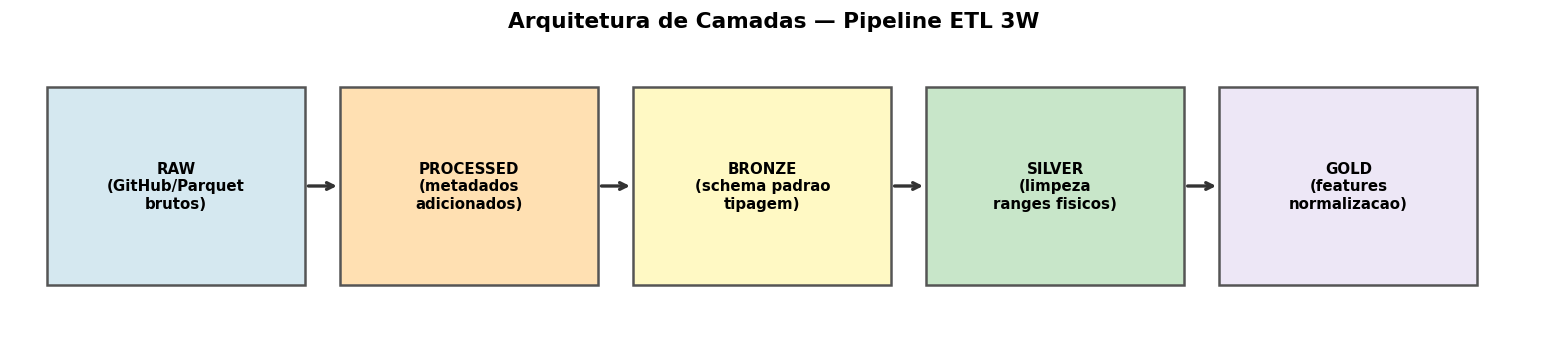

In [2]:
# Dicionário completo de classes e eventos do dataset 3W
EVENT_LABELS = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',        # Aumento abrupto de BSW (água produzida)
    2: 'Spurious Closure of DHSV',      # Fechamento espúrio da DHSV (válvula de fundo)
    3: 'Severe Slugging',               # Golfadas severas de gás/líquido
    4: 'Flow Instability',              # Instabilidade de fluxo (casing heading)
    5: 'Rapid Productivity Loss',       # Perda rápida de produtividade
    6: 'Quick Restriction in PCK',      # Restrição rápida na válvula de produção
    7: 'Scaling in PCK',               # Incrustação (scaling) na válvula de produção
    8: 'Hydrate in Production Line',    # Hidrato na linha de produção
    9: 'Undefined/Other',              # Evento indefinido (não usado no treinamento)
}

SENSOR_COLUMNS = [
    'P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
    'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL',
]

# Ranges físicos válidos (extraídos da documentação do 3W e usados na camada Silver)
SENSOR_PHYSICAL_RANGES = {
    'P-PDG':      (0.0,   1000.0),
    'P-TPT':      (0.0,   1000.0),
    'T-TPT':      (-10.0, 200.0),
    'P-MON-CKP':  (0.0,   1000.0),
    'T-JUS-CKP':  (-10.0, 200.0),
    'P-JUS-CKGL': (0.0,   1000.0),
    'T-JUS-CKGL': (-10.0, 200.0),
    'QGL':        (0.0,   5000.0),
}

# Paleta de cores por classe
CLASS_COLORS = {
    0: '#4C9BE8', 1: '#F4A261', 2: '#E63946', 3: '#457B9D',
    4: '#2A9D8F', 5: '#E9C46A', 6: '#8338EC', 7: '#06D6A0', 8: '#FB8500',
}

# Visualização: arquitetura de camadas
fig, ax = plt.subplots(figsize=(13, 3))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3)
ax.axis('off')

camadas = [
    (0.3,  '#D5E8F0', 'RAW\n(GitHub/Parquet\nbrutos)'),
    (2.8,  '#FFE0B2', 'PROCESSED\n(metadados\nadicionados)'),
    (5.3,  '#FFF9C4', 'BRONZE\n(schema padrao\ntipagem)'),
    (7.8,  '#C8E6C9', 'SILVER\n(limpeza\nranges fisicos)'),
    (10.3, '#EDE7F6', 'GOLD\n(features\nnormalizacao)'),
]
for x, cor, texto in camadas:
    rect = plt.Rectangle((x, 0.5), 2.2, 2, color=cor, ec='#555', lw=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 1.1, 1.5, texto, ha='center', va='center', fontsize=9, fontweight='bold')
    if x < 10.3:
        ax.annotate('', xy=(x + 2.5, 1.5), xytext=(x + 2.2, 1.5),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=2))

ax.set_title('Arquitetura de Camadas — Pipeline ETL 3W', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Célula 3 — Geração de Dados de Exemplo (Sintéticos)

Para garantir que o notebook seja executável independentemente dos dados reais,
geramos séries temporais sintéticas com as características estatísticas conhecidas
do dataset 3W. Quando os dados reais estão disponíveis, eles são carregados.

> **Nota:** Os dados sintéticos foram gerados com base nas distribuições reais
> documentadas nos scripts `etl_bronze_silver_gold.py` e nos ranges físicos do 3W.

In [3]:
def gerar_dados_sinteticos(n_amostras=50000, seed=42):
    """
    Gera dados sintéticos com distribuição estatística próxima ao dataset 3W real.
    Inclui:
      - Padrões típicos de operação normal (classe 0)
      - Perturbações características de cada evento
      - Valores fora de range (para simular outliers a filtrar na Silver)
      - Valores nulos (para simular falhas de sensor)
    """
    rng = np.random.default_rng(seed)
    n_por_classe = n_amostras // 9

    frames = []
    t_base = pd.date_range('2013-11-01', periods=1, freq='2min')[0]

    for classe in range(9):
        n = n_por_classe if classe > 0 else n_amostras - 8 * n_por_classe
        # Timestamp sequencial com frequência de 2 minutos
        timestamps = pd.date_range(t_base, periods=n, freq='2min')
        t_base = timestamps[-1] + pd.Timedelta('2min')

        # Pressão de fundo (P-PDG): variação lenta, alta correlação com P-TPT
        p_pdg_base = rng.normal(350, 30, n).clip(50, 900)
        # Evento 3 (Slugging): oscilações de pressão
        if classe == 3:
            p_pdg_base += 80 * np.sin(np.linspace(0, 20 * np.pi, n))
        # Evento 2 (DHSV Closure): queda abrupta
        if classe == 2:
            queda = np.zeros(n)
            queda[n//2:] = -200
            p_pdg_base += queda

        # Pressão no tubo de produção: correlacionada com P-PDG
        p_tpt = p_pdg_base * 0.6 + rng.normal(0, 15, n)

        # Temperaturas: mais estáveis
        t_tpt = rng.normal(70, 8, n).clip(10, 180)
        t_jus_ckp = rng.normal(65, 6, n).clip(10, 180)
        t_jus_ckgl = rng.normal(55, 5, n).clip(10, 180)

        # Pressão montante válvula CKP
        p_mon_ckp = p_tpt * 0.95 + rng.normal(0, 10, n)
        # Pressão jusante válvula gás lift
        p_jus_ckgl = rng.normal(120, 20, n).clip(10, 500)

        # Evento 8 (Hydrate): redução de vazão e pressão
        if classe == 8:
            p_jus_ckgl *= 0.5

        # Vazão de gás lift
        qgl = rng.normal(1800, 400, n).clip(0, 4800)
        # Evento 5 (Prod. Loss): redução de QGL
        if classe == 5:
            qgl *= 0.3

        df_c = pd.DataFrame({
            'timestamp':    timestamps,
            'ID_Poco':      f'WELL-{rng.choice(["00002", "00004", "00006"]):s}',
            'class':        np.int8(classe),
            'nome_evento':  EVENT_LABELS[classe],
            'P-PDG':        p_pdg_base.astype('float32'),
            'P-TPT':        p_tpt.clip(0, 1000).astype('float32'),
            'T-TPT':        t_tpt.astype('float32'),
            'P-MON-CKP':    p_mon_ckp.clip(0, 1000).astype('float32'),
            'T-JUS-CKP':    t_jus_ckp.astype('float32'),
            'P-JUS-CKGL':   p_jus_ckgl.astype('float32'),
            'T-JUS-CKGL':   t_jus_ckgl.astype('float32'),
            'QGL':          qgl.astype('float32'),
        })

        # Injeta ~3% de valores nulos (simula falhas de sensor)
        for col in SENSOR_COLUMNS:
            mask = rng.random(n) < 0.03
            df_c.loc[mask, col] = np.nan

        # Injeta ~0.5% de valores fora do range físico
        for col, (vmin, vmax) in SENSOR_PHYSICAL_RANGES.items():
            mask = rng.random(n) < 0.005
            df_c.loc[mask, col] = rng.choice([vmin - 50, vmax + 100])

        frames.append(df_c)

    df = pd.concat(frames, ignore_index=True)
    return df


# Carrega dados reais ou gera sintéticos
if USE_REAL_DATA:
    try:
        import pyarrow  # noqa
        df_bronze = pd.read_parquet(BRONZE_DIR / 'bronze_3w_all.parquet')
        # Amostra para o notebook (máximo 200k linhas)
        if len(df_bronze) > 200_000:
            df_bronze = df_bronze.sample(200_000, random_state=42).reset_index(drop=True)
        print(f'Dados reais carregados: {df_bronze.shape}')
    except Exception as e:
        print(f'Erro ao carregar dados reais: {e}\nUsando dados sintéticos.')
        USE_REAL_DATA = False
        df_bronze = gerar_dados_sinteticos()
else:
    df_bronze = gerar_dados_sinteticos()
    print(f'Dados sintéticos gerados: {df_bronze.shape}')

print(f'Colunas: {list(df_bronze.columns)}')
df_bronze.head(3)

Dados reais carregados: (200000, 13)
Colunas: ['timestamp', 'ID_Poco', 'class', 'nome_evento', 'P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL', 'bronze_at']


,timestamp,ID_Poco,class,nome_evento,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,bronze_at
0,2018-06-21 23:07:02,00006,7,Scaling in PCK,-1.180116e+42,21465740.0,116.9499,12732870.0,61.84384,3301229.0,NaN,0.0,2026-06-18 10:45:16
1,2017-08-01 04:36:21,00006,1,Abrupt Increase of BSW,4.485805e+07,18373560.0,118.4823,2544060.0,78.98711,1307087.0,NaN,0.0,2026-06-18 10:45:16
2,2017-02-08 16:48:04,00006,0,Normal,0.000000e+00,18233910.0,118.7485,2492555.0,80.36447,-496225.0,NaN,0.0,2026-06-18 10:45:16


## Célula 4 — Análise Estatística Descritiva

A análise estatística é o primeiro passo após a ingestão. Calculamos as métricas
fundamentais para entender a distribuição e qualidade dos dados brutos:

- **Mínimo / Máximo**: detecta outliers e erros de sensor
- **Média / Desvio Padrão**: caracteriza o regime de operação normal
- **Percentis (P25, P50, P75, P99)**: identifica distribuições assimétricas
- **Taxa de nulos**: quantifica falhas de sensor por variável

In [4]:
# Calcula estatísticas descritivas completas para cada sensor
stats_rows = []
for sensor in SENSOR_COLUMNS:
    if sensor not in df_bronze.columns:
        continue
    s = df_bronze[sensor].dropna()
    vmin, vmax = SENSOR_PHYSICAL_RANGES[sensor]
    n_total = len(df_bronze)
    n_nulos = df_bronze[sensor].isna().sum()
    n_invalidos = ((s < vmin) | (s > vmax)).sum()

    stats_rows.append({
        'Sensor':    sensor,
        'Contagem':  len(s),
        'Nulos (%)': round(n_nulos / n_total * 100, 2),
        'Inválidos': n_invalidos,
        'Min':       round(float(s.min()),   2),
        'P25':       round(float(s.quantile(0.25)), 2),
        'Mediana':   round(float(s.median()), 2),
        'Media':     round(float(s.mean()),   2),
        'P75':       round(float(s.quantile(0.75)), 2),
        'P99':       round(float(s.quantile(0.99)), 2),
        'Max':       round(float(s.max()),   2),
        'Std':       round(float(s.std()),   2),
        'Range físico': f'{vmin} – {vmax}',
    })

df_stats = pd.DataFrame(stats_rows).set_index('Sensor')
print('=== Estatísticas Descritivas — Dataset 3W ===')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 150)
display(df_stats)

=== Estatísticas Descritivas — Dataset 3W ===


,Contagem,Nulos (%),Inválidos,Min,P25,Mediana,Media,P75,P99,Max,Std,Range físico
Sensor,,,,,,,,,,,,
P-PDG,199968,0.02,48656,-1.180116e+42,0.00,0.00,-3.879072e+40,0.00,44858050.00,44858050.00,2.104116e+41,0.0 – 1000.0
P-TPT,199955,0.02,199955,7.166968e+06,8409906.00,16131210.00,1.372114e+07,18094260.00,21206400.00,21525590.00,5.286004e+06,0.0 – 1000.0
T-TPT,199955,0.02,0,1.230000e+01,116.58,117.36,1.166500e+02,117.93,118.89,119.60,3.650000e+00,-10.0 – 200.0
P-MON-CKP,75531,62.23,75531,1.927140e+06,2496532.50,9710817.00,8.272424e+06,12244140.00,12501271.00,12848440.00,4.333760e+06,0.0 – 1000.0
T-JUS-CKP,75505,62.25,0,5.959000e+01,61.64,68.17,6.963000e+01,79.54,80.37,81.45,7.930000e+00,-10.0 – 200.0
P-JUS-CKGL,62213,68.89,62213,-4.976717e+05,134133.10,1146197.00,1.598756e+06,2162020.00,7508916.00,7965906.00,2.312593e+06,0.0 – 1000.0
T-JUS-CKGL,0,100.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10.0 – 200.0
QGL,62213,68.89,0,0.000000e+00,0.00,0.00,0.000000e+00,0.00,0.00,0.05,0.000000e+00,0.0 – 5000.0


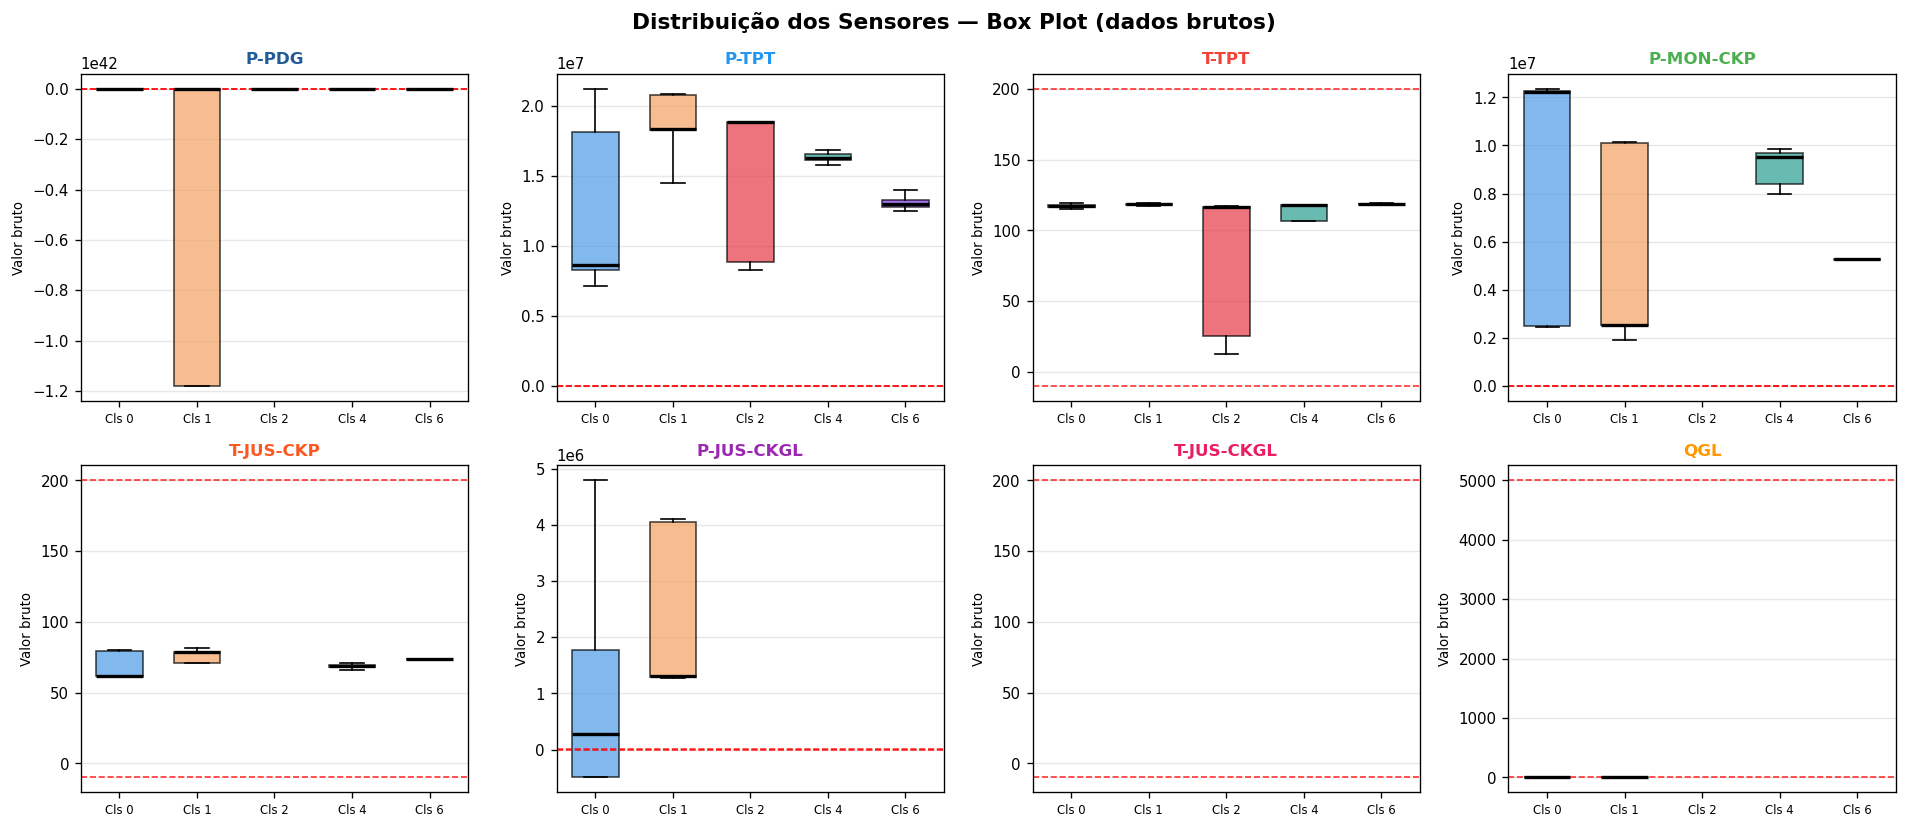

Legenda: Caixas coloridas = distribuição por classe de evento | Linhas vermelhas = limites físicos válidos


In [5]:
# Visualização: boxplots dos 8 sensores normalizados para comparação
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Distribuição dos Sensores — Box Plot (dados brutos)', fontsize=13, fontweight='bold')

cores_sensores = {
    'P-PDG': '#1F5C99', 'P-TPT': '#2196F3', 'T-TPT': '#F44336',
    'P-MON-CKP': '#4CAF50', 'T-JUS-CKP': '#FF5722',
    'P-JUS-CKGL': '#9C27B0', 'T-JUS-CKGL': '#E91E63', 'QGL': '#FF9800',
}

for ax, sensor in zip(axes.flatten(), SENSOR_COLUMNS):
    dados = df_bronze[sensor].dropna()
    vmin, vmax = SENSOR_PHYSICAL_RANGES[sensor]

    # Boxplot por classe (até 5 classes para legibilidade)
    classes_presentes = sorted(df_bronze['class'].unique())[:5]
    dados_por_classe = [
        df_bronze[df_bronze['class'] == cls][sensor].dropna().values
        for cls in classes_presentes
    ]

    bp = ax.boxplot(dados_por_classe, patch_artist=True, showfliers=False,
                    widths=0.6, medianprops=dict(color='black', lw=2))

    # Colore cada box com a cor da classe
    for patch, cls in zip(bp['boxes'], classes_presentes):
        patch.set_facecolor(CLASS_COLORS.get(cls, '#aaa'))
        patch.set_alpha(0.7)

    # Linhas de range físico válido
    ax.axhline(vmin, color='red', linestyle='--', lw=1, alpha=0.8, label=f'Min físico: {vmin}')
    ax.axhline(vmax, color='red', linestyle='--', lw=1, alpha=0.8, label=f'Max físico: {vmax}')

    ax.set_title(sensor, fontsize=10, fontweight='bold',
                 color=cores_sensores.get(sensor, 'black'))
    ax.set_xticklabels([f'Cls {c}' for c in classes_presentes], fontsize=7)
    ax.set_ylabel('Valor bruto', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('Legenda: Caixas coloridas = distribuição por classe de evento | Linhas vermelhas = limites físicos válidos')

## Célula 5 — Análise de Pressão e Temperatura

Os sensores do 3W medem variáveis físicas em dois domínios principais:

**Pressão** (4 sensores): P-PDG, P-TPT, P-MON-CKP, P-JUS-CKGL
- Altamente correlacionados entre si
- Eventos de slugging e DHSV geram assinaturas distintas de pressão

**Temperatura** (3 sensores): T-TPT, T-JUS-CKP, T-JUS-CKGL
- Mais estáveis que pressão
- Importantes para detecção de hidrato (queda de temperatura)

**Vazão de gás lift** (1 sensor): QGL
- Controlado artificialmente — anômalos indicam falha no sistema de gas lift

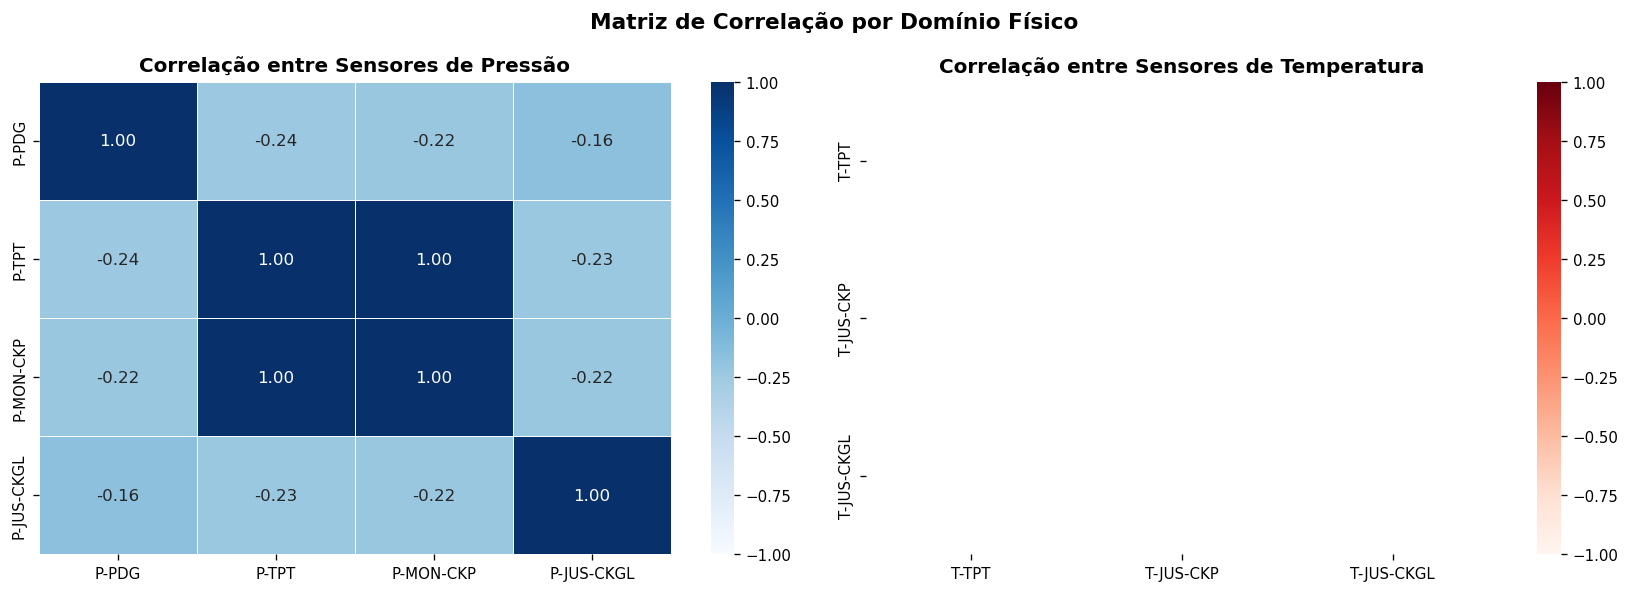

In [6]:
# Correlação entre os sensores de pressão
sensores_pressao = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']
sensores_temp    = ['T-TPT', 'T-JUS-CKP', 'T-JUS-CKGL']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de correlação — pressões
df_pressao = df_bronze[sensores_pressao].dropna()
corr_p = df_pressao.corr()
mask_p = np.zeros_like(corr_p, dtype=bool)
mask_p[np.triu_indices_from(mask_p)] = True
sns.heatmap(corr_p, ax=axes[0], annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Correlação entre Sensores de Pressão', fontweight='bold')

# Matriz de correlação — temperaturas
df_temp = df_bronze[sensores_temp].dropna()
corr_t = df_temp.corr()
sns.heatmap(corr_t, ax=axes[1], annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Correlação entre Sensores de Temperatura', fontweight='bold')

plt.suptitle('Matriz de Correlação por Domínio Físico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

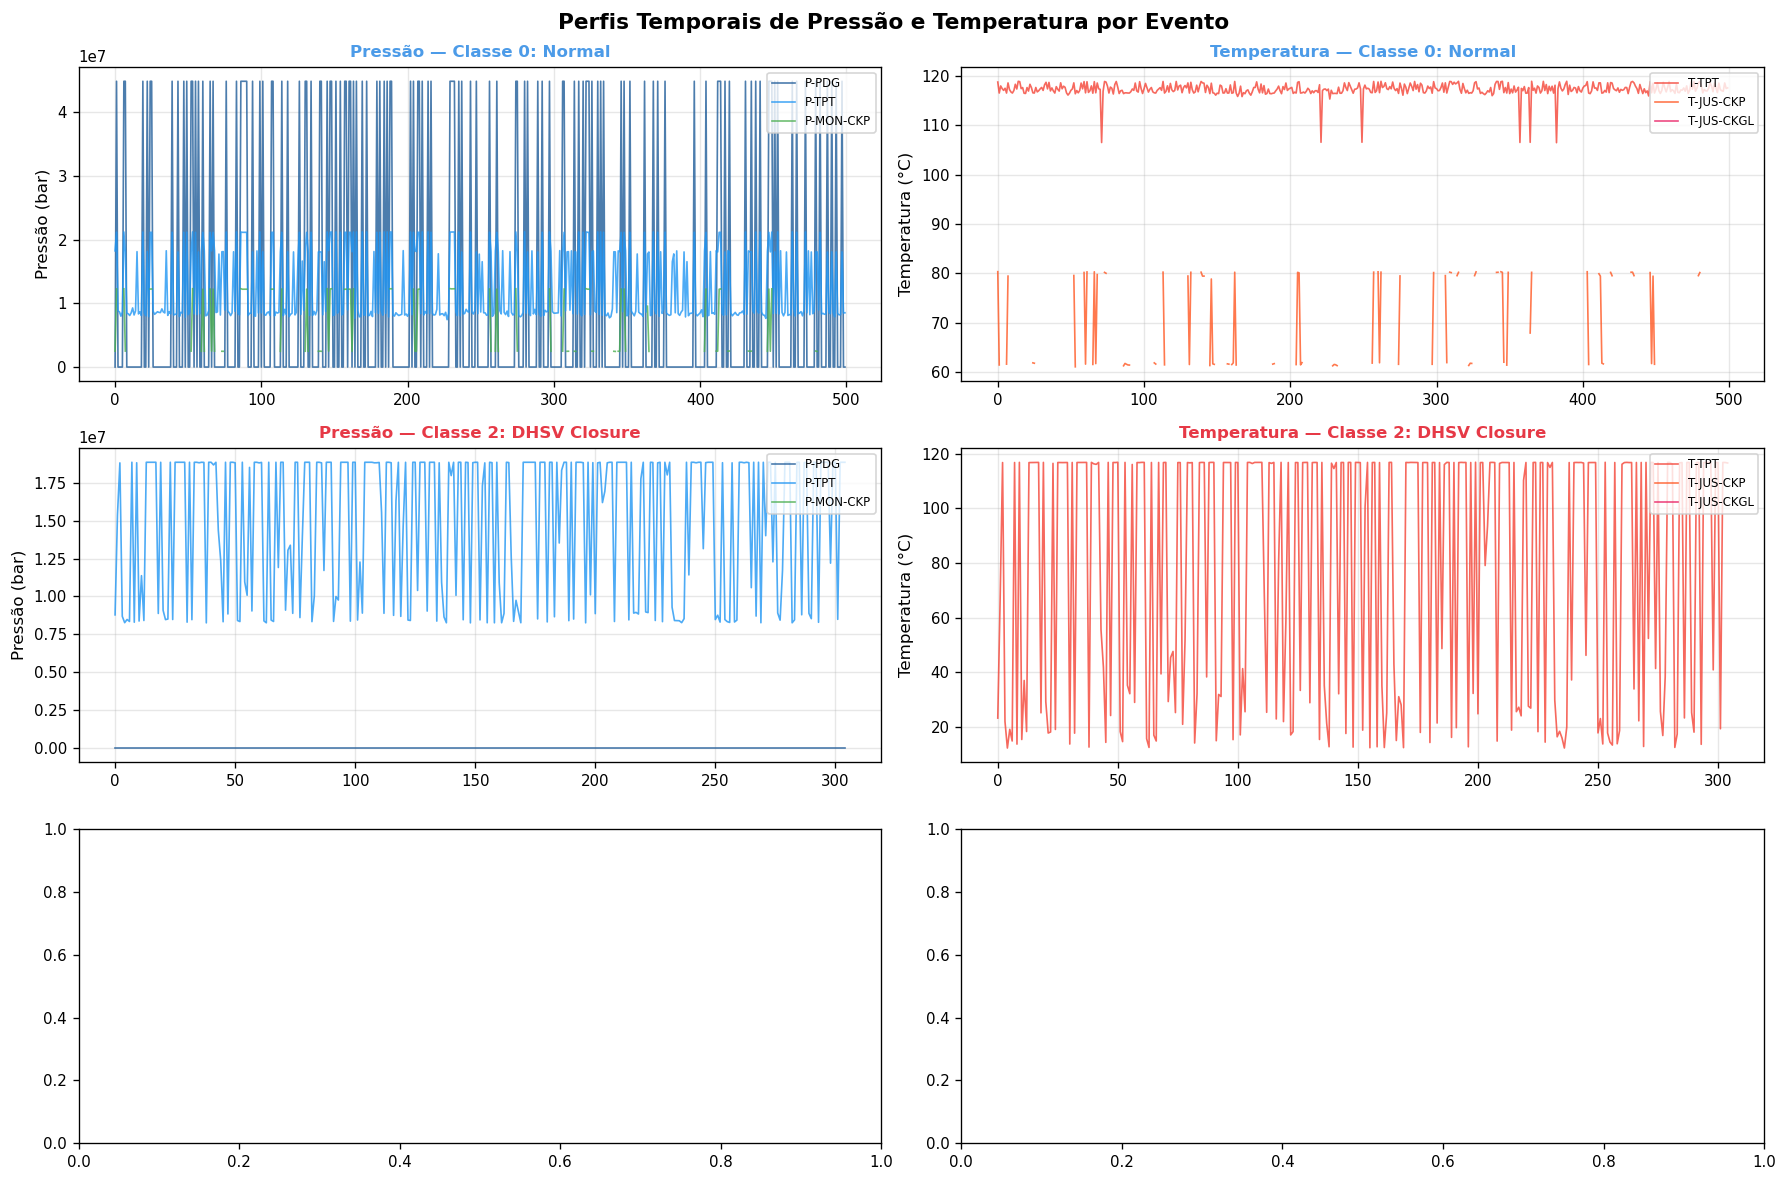

In [7]:
# Série temporal de P-PDG e T-TPT comparadas para eventos distintos
# Mostra como o padrão temporal difere por classe
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Perfis Temporais de Pressão e Temperatura por Evento', fontsize=13, fontweight='bold')

pares_classes = [(0, 'Normal'), (2, 'DHSV Closure'), (3, 'Severe Slugging')]

for idx, (cls, nome) in enumerate(pares_classes):
    df_cls = df_bronze[df_bronze['class'] == cls].head(500).reset_index(drop=True)
    if df_cls.empty:
        continue
    x = np.arange(len(df_cls))

    # Pressão
    ax_p = axes[idx, 0]
    for sensor, cor in [('P-PDG', '#1F5C99'), ('P-TPT', '#2196F3'),
                         ('P-MON-CKP', '#4CAF50')]:
        if sensor in df_cls.columns:
            ax_p.plot(x, df_cls[sensor], lw=1, alpha=0.8, label=sensor, color=cor)
    ax_p.set_title(f'Pressão — Classe {cls}: {nome}', fontsize=10,
                   color=CLASS_COLORS.get(cls, 'black'), fontweight='bold')
    ax_p.set_ylabel('Pressão (bar)')
    ax_p.legend(fontsize=7, loc='upper right')
    ax_p.grid(alpha=0.3)

    # Temperatura
    ax_t = axes[idx, 1]
    for sensor, cor in [('T-TPT', '#F44336'), ('T-JUS-CKP', '#FF5722'),
                         ('T-JUS-CKGL', '#E91E63')]:
        if sensor in df_cls.columns:
            ax_t.plot(x, df_cls[sensor], lw=1, alpha=0.8, label=sensor, color=cor)
    ax_t.set_title(f'Temperatura — Classe {cls}: {nome}', fontsize=10,
                   color=CLASS_COLORS.get(cls, 'black'), fontweight='bold')
    ax_t.set_ylabel('Temperatura (°C)')
    ax_t.legend(fontsize=7, loc='upper right')
    ax_t.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Célula 6 — Distribuição de Classes e Desbalanceamento

O dataset 3W é **fortemente desbalanceado**: a operação normal (Classe 0) domina
enquanto alguns eventos são raros (ex: DHSV Closure, Hydrate).

Este desbalanceamento impacta diretamente o treinamento — modelos sem correção
tendem a classificar tudo como 'Normal'. A estratégia adotada foi `class_weight='balanced'`.

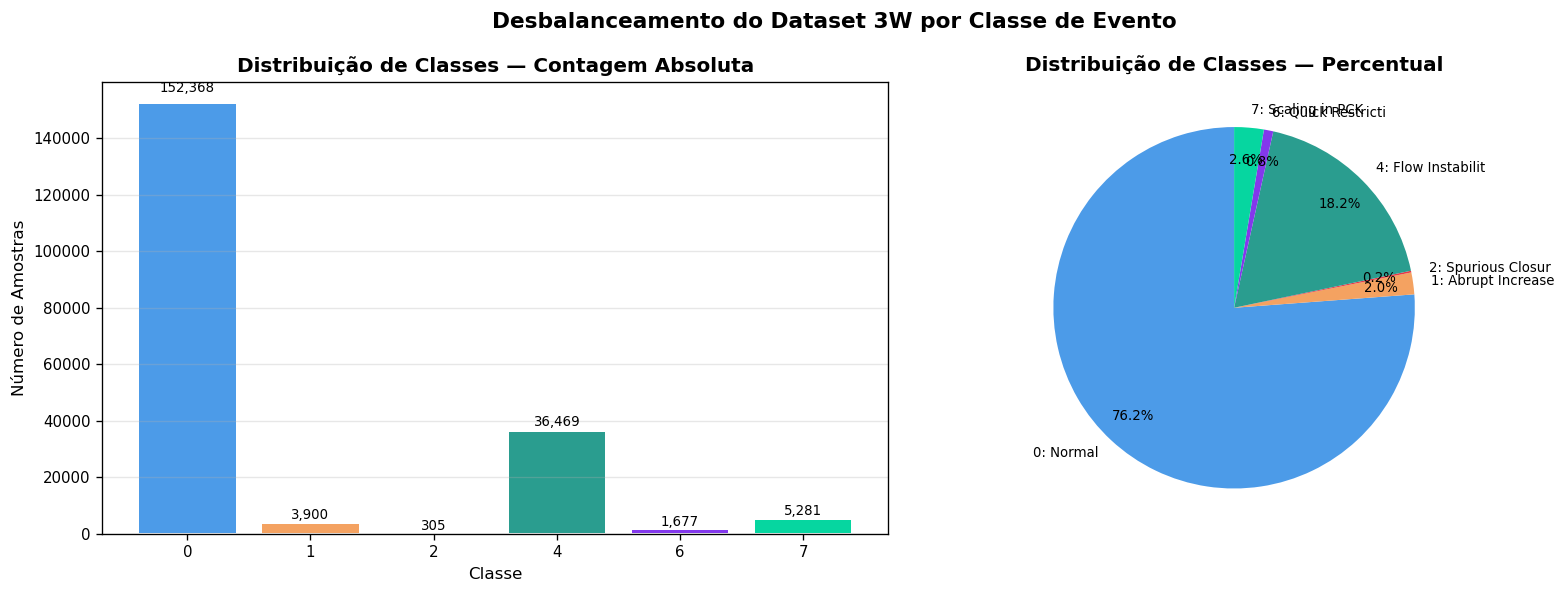

  Classe  Evento                                      Amostras  Percentual   Peso bal.
-------------------------------------------------------------------------------------
       0  Normal                                       152,368      76.18%        0.22
       1  Abrupt Increase of BSW                         3,900       1.95%        8.55
       2  Spurious Closure of DHSV                         305       0.15%      109.29
       4  Flow Instability                              36,469      18.23%        0.91
       6  Quick Restriction in PCK                       1,677       0.84%       19.88
       7  Scaling in PCK                                 5,281       2.64%        6.31


In [8]:
# Distribuição de classes
dist = df_bronze['class'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras — contagem
cores = [CLASS_COLORS.get(int(cls), '#aaa') for cls in dist.index]
bars = axes[0].bar([f'{int(c)}' for c in dist.index], dist.values,
                    color=cores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribuição de Classes — Contagem Absoluta', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Número de Amostras')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Pizza — percentual
labels = [f"{int(c)}: {EVENT_LABELS.get(int(c), '?')[:15]}" for c in dist.index]
axes[1].pie(dist.values, labels=labels, colors=cores,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 8}, pctdistance=0.82)
axes[1].set_title('Distribuição de Classes — Percentual', fontweight='bold')

plt.suptitle('Desbalanceamento do Dataset 3W por Classe de Evento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabela resumo
print(f'{"Classe":>8}  {"Evento":40}  {"Amostras":>10}  {"Percentual":>10}  {"Peso bal.":>10}')
print('-' * 85)
for cls, cnt in dist.items():
    peso = len(df_bronze) / (len(dist) * cnt)  # class_weight='balanced'
    print(f'{int(cls):>8}  {EVENT_LABELS.get(int(cls), "?"):40}  {cnt:>10,}  '
          f'{cnt/len(df_bronze)*100:>9.2f}%  {peso:>10.2f}')

## Célula 7 — Camada BRONZE: Schema Padrão e Tipagem

A camada Bronze é a **primeira camada de qualidade**. Objetivo: garantir que todos
os dados tenham o mesmo schema, tipos corretos e metadados de rastreabilidade.

**Transformações aplicadas:**
- `timestamp` → `datetime64[ns]` (conversão de índice para coluna)
- Sensores → `float64` (padroniza tipos numéricos mistos)
- `class` → `int8` (economia de memória — 256 valores possíveis)
- Remoção de registros com `class < 0` (labels inválidos)
- Adição de `nome_evento` (label textual)
- Adição de `bronze_at` (timestamp de processamento para rastreabilidade)

In [9]:
# Simula a transformação Bronze: tipagem e metadados
def aplicar_bronze(df_raw):
    """
    Aplica as transformações da camada Bronze ao dataframe bruto.
    Espelha a lógica de run_bronze() em etl_bronze_silver_gold.py.
    """
    df = df_raw.copy()

    # Normaliza timestamp
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Sensores -> float64
    for col in SENSOR_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

    # Classe -> int8
    if 'class' in df.columns:
        df['class'] = pd.to_numeric(df['class'], errors='coerce').fillna(-1).astype('int8')

    # Remove registros com class inválida
    removidos = (df['class'] < 0).sum()
    df = df[df['class'] >= 0].copy()

    # Adiciona label textual
    if 'nome_evento' not in df.columns:
        df['nome_evento'] = df['class'].map(EVENT_LABELS).fillna('Desconhecido')

    # Metadado de rastreabilidade
    df['bronze_at'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

    print(f'Bronze: {removidos} registros com class < 0 removidos.')
    return df


df_bronze_proc = aplicar_bronze(df_bronze)

# Compara tipos antes e depois
print('\n=== Tipos de dados — ANTES e DEPOIS da camada Bronze ===')
colunas_comp = SENSOR_COLUMNS[:4] + ['class', 'timestamp']
comp = pd.DataFrame({
    'Tipo RAW':    [str(df_bronze[c].dtype) if c in df_bronze.columns else '-' for c in colunas_comp],
    'Tipo Bronze': [str(df_bronze_proc[c].dtype) if c in df_bronze_proc.columns else '-' for c in colunas_comp],
}, index=colunas_comp)
display(comp)

# Visualiza impacto de memória
mem_antes  = df_bronze[SENSOR_COLUMNS].memory_usage(deep=True).sum() / 1e6
mem_depois = df_bronze_proc[SENSOR_COLUMNS].memory_usage(deep=True).sum() / 1e6
print(f'\nMemória sensores — RAW: {mem_antes:.1f} MB | Bronze: {mem_depois:.1f} MB')
print(f'Schema Bronze: {list(df_bronze_proc.columns)}')

Bronze: 0 registros com class < 0 removidos.

=== Tipos de dados — ANTES e DEPOIS da camada Bronze ===


,Tipo RAW,Tipo Bronze
P-PDG,float64,float64
P-TPT,float64,float64
T-TPT,float64,float64
P-MON-CKP,float64,float64
class,int8,int8
timestamp,datetime64[ns],datetime64[ns]



Memória sensores — RAW: 12.8 MB | Bronze: 12.8 MB
Schema Bronze: ['timestamp', 'ID_Poco', 'class', 'nome_evento', 'P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL', 'bronze_at']


## Célula 8 — Camada SILVER: Limpeza e Validação de Ranges Físicos

A Silver transforma dados brutos em dados **confiáveis para análise**.
Dois tipos de problemas são tratados:

1. **Leituras fisicamente impossíveis**: valores abaixo/acima dos limites físicos dos sensores
   são substituídos por NaN e depois preenchidos por forward fill
2. **Valores nulos**: forward fill + backward fill por poço (preserva continuidade temporal)
3. **Duplicatas de timestamp**: mantém apenas a primeira leitura de cada instante por poço

**Por que forward fill e não interpolação linear?**
Sensores industriais reportam o último valor válido quando há falha de comunicação.
O forward fill é fisicamente mais realista que interpolação nesse contexto.

Silver: 791 duplicatas de timestamp removidas.
Silver: 0 linhas com todos sensores nulos removidas.


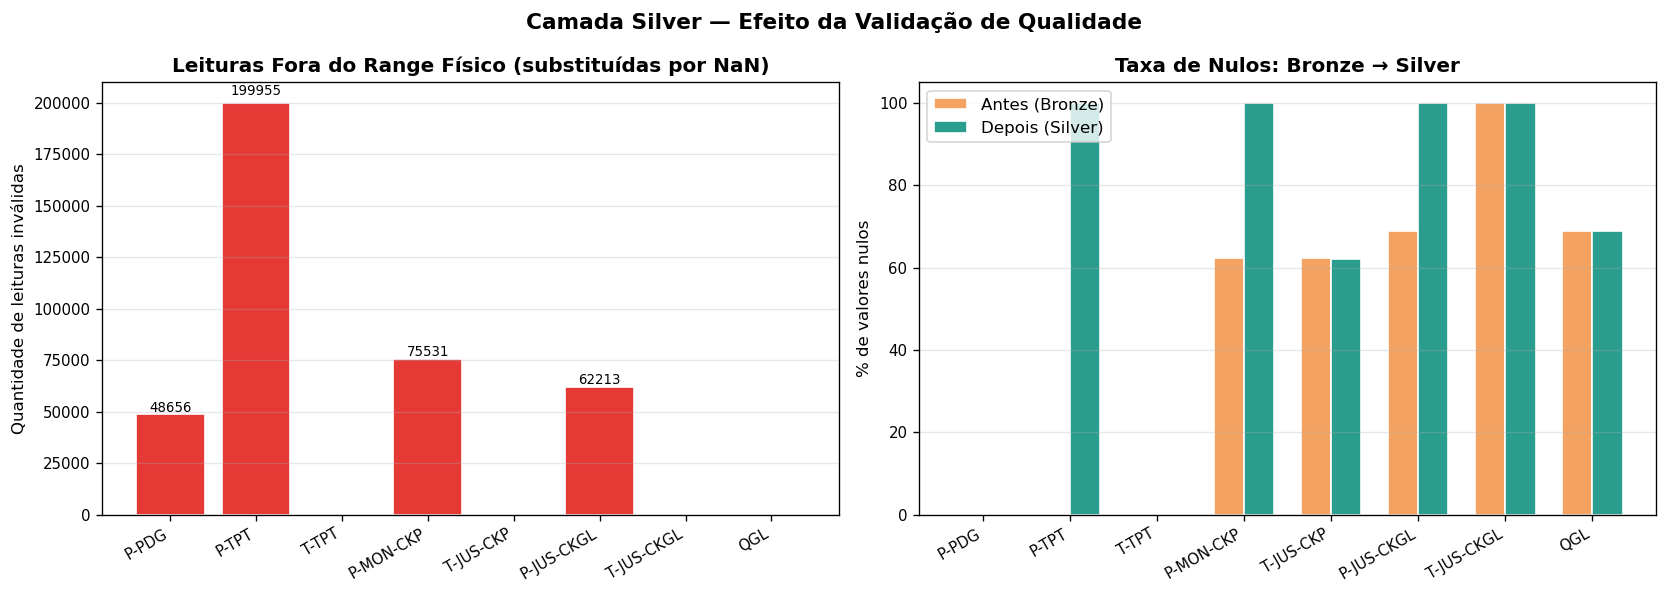


Silver: 199,209 linhas x 14 colunas


In [10]:
# Demonstra o efeito da validação de ranges físicos
def aplicar_silver(df_bronze):
    """
    Aplica as transformações da camada Silver.
    Espelha run_silver() em etl_bronze_silver_gold.py.
    """
    df = df_bronze.copy()
    invalidos_por_sensor = {}

    # 1. Invalida leituras fora dos ranges físicos
    for sensor, (vmin, vmax) in SENSOR_PHYSICAL_RANGES.items():
        if sensor not in df.columns:
            continue
        mask = (df[sensor] < vmin) | (df[sensor] > vmax)
        n_inv = mask.sum()
        invalidos_por_sensor[sensor] = n_inv
        if n_inv > 0:
            df.loc[mask, sensor] = np.nan

    # 2. Forward fill + backward fill por poço
    if 'ID_Poco' in df.columns and 'timestamp' in df.columns:
        df = df.sort_values(['ID_Poco', 'timestamp'])
        for sensor in SENSOR_COLUMNS:
            if sensor not in df.columns:
                continue
            df[sensor] = (
                df.groupby('ID_Poco')[sensor]
                .transform(lambda s: s.ffill().bfill())
            )

    # 3. Remove duplicatas de timestamp por poço
    if 'timestamp' in df.columns and 'ID_Poco' in df.columns:
        n_antes = len(df)
        df = df.drop_duplicates(subset=['ID_Poco', 'timestamp'], keep='first')
        print(f'Silver: {n_antes - len(df)} duplicatas de timestamp removidas.')

    # 4. Remove linhas com todos os sensores nulos
    sensor_presentes = [c for c in SENSOR_COLUMNS if c in df.columns]
    n_antes = len(df)
    df = df.dropna(subset=sensor_presentes, how='all')
    print(f'Silver: {n_antes - len(df)} linhas com todos sensores nulos removidas.')

    df['silver_at'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    return df, invalidos_por_sensor


df_silver, inv_por_sensor = aplicar_silver(df_bronze_proc)

# Visualiza valores inválidos por sensor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: quantidade de inválidos
sensores = list(inv_por_sensor.keys())
qtds = list(inv_por_sensor.values())
cores_bar = ['#E53935' if q > 0 else '#43A047' for q in qtds]
axes[0].bar(sensores, qtds, color=cores_bar, edgecolor='white')
axes[0].set_title('Leituras Fora do Range Físico (substituídas por NaN)', fontweight='bold')
axes[0].set_ylabel('Quantidade de leituras inválidas')
axes[0].set_xticklabels(sensores, rotation=30, ha='right')
for i, (sensor, qtd) in enumerate(zip(sensores, qtds)):
    if qtd > 0:
        axes[0].text(i, qtd * 1.02, str(qtd), ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Antes/depois: taxa de nulos
nulos_antes  = {s: df_bronze_proc[s].isna().mean() * 100 for s in SENSOR_COLUMNS if s in df_bronze_proc.columns}
nulos_depois = {s: df_silver[s].isna().mean() * 100 for s in SENSOR_COLUMNS if s in df_silver.columns}
x = np.arange(len(SENSOR_COLUMNS))
w = 0.35
axes[1].bar(x - w/2, [nulos_antes.get(s, 0) for s in SENSOR_COLUMNS],
            w, label='Antes (Bronze)', color='#F4A261', edgecolor='white')
axes[1].bar(x + w/2, [nulos_depois.get(s, 0) for s in SENSOR_COLUMNS],
            w, label='Depois (Silver)', color='#2A9D8F', edgecolor='white')
axes[1].set_title('Taxa de Nulos: Bronze → Silver', fontweight='bold')
axes[1].set_ylabel('% de valores nulos')
axes[1].set_xticks(x)
axes[1].set_xticklabels(SENSOR_COLUMNS, rotation=30, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Camada Silver — Efeito da Validação de Qualidade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nSilver: {df_silver.shape[0]:,} linhas x {df_silver.shape[1]} colunas')

## Célula 9 — Teoria de Scaling (Normalização)

Antes de aplicar ML, os dados precisam ser **normalizados** para que sensores com escalas
diferentes (pressão em bar vs temperatura em °C vs vazão em m³/d) não distorçam o modelo.

### Métodos Comparados

| Método | Fórmula | Propriedade | Quando usar |
|--------|---------|-------------|-------------|
| **Z-score** | `(x - μ) / σ` | Preserva outliers | Distribuição aproximadamente gaussiana |
| **Min-Max** | `(x - min) / (max - min)` | Escala [0,1] | Sem outliers extremos |
| **Robust** | `(x - Q50) / (Q75 - Q25)` | Resistente a outliers | Dados com muitos outliers |

### Por que Z-score foi escolhido?
- Os sensores do 3W têm distribuições aproximadamente gaussianas em regime normal
- Árvores de decisão (RF, XGBoost, LightGBM) **não requerem** normalização, mas ela
  beneficia a convergência e comparabilidade das features de rolling
- **Regra crítica**: os parâmetros μ e σ são calculados **SOMENTE no conjunto de treino**
  e aplicados igualmente ao val e test — evita data leakage

ValueError: autodetected range of [nan, nan] is not finite

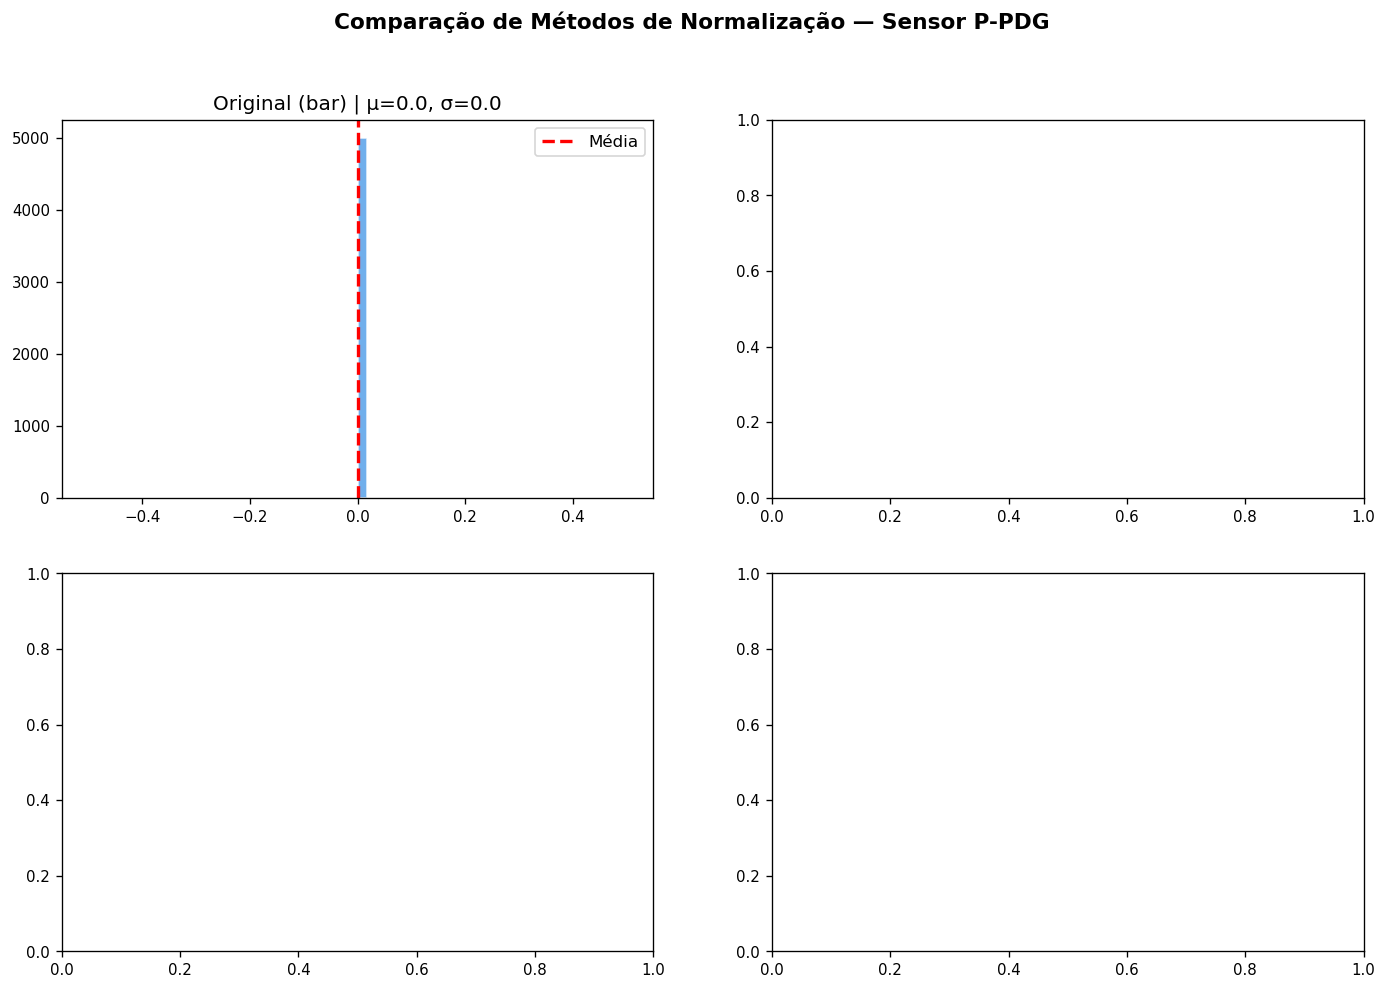

In [11]:
# Comparação visual dos três métodos de normalização no sensor P-PDG
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

sensor_demo = 'P-PDG'
dados_demo = df_silver[sensor_demo].dropna().values[:5000]

# Aplica os três métodos
z_score = (dados_demo - dados_demo.mean()) / dados_demo.std()
minmax  = (dados_demo - dados_demo.min()) / (dados_demo.max() - dados_demo.min() + 1e-8)
q25, q50, q75 = np.percentile(dados_demo, [25, 50, 75])
robust  = (dados_demo - q50) / (q75 - q25 + 1e-8)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Comparação de Métodos de Normalização — Sensor {sensor_demo}', fontsize=13, fontweight='bold')

# Dados originais
axes[0, 0].hist(dados_demo, bins=60, color='#4C9BE8', edgecolor='white', alpha=0.8)
axes[0, 0].set_title(f'Original (bar) | μ={dados_demo.mean():.1f}, σ={dados_demo.std():.1f}')
axes[0, 0].axvline(dados_demo.mean(), color='red', lw=2, linestyle='--', label='Média')
axes[0, 0].legend()

# Z-score
axes[0, 1].hist(z_score, bins=60, color='#2A9D8F', edgecolor='white', alpha=0.8)
axes[0, 1].set_title(f'Z-score | μ={z_score.mean():.1f}, σ={z_score.std():.1f}')
axes[0, 1].axvline(0, color='red', lw=2, linestyle='--')
axes[0, 1].axvline(-2, color='orange', lw=1, linestyle=':', label='±2σ')
axes[0, 1].axvline(2,  color='orange', lw=1, linestyle=':')
axes[0, 1].legend()

# Min-Max
axes[1, 0].hist(minmax, bins=60, color='#E9C46A', edgecolor='white', alpha=0.8)
axes[1, 0].set_title(f'Min-Max [0,1] | min={minmax.min():.2f}, max={minmax.max():.2f}')
axes[1, 0].axvline(0.5, color='red', lw=2, linestyle='--', label='Centro')
axes[1, 0].legend()

# Robust
axes[1, 1].hist(robust, bins=60, color='#E63946', edgecolor='white', alpha=0.8)
axes[1, 1].set_title(f'Robust (IQR) | Q25={q25:.1f}, Q50={q50:.1f}, Q75={q75:.1f}')
axes[1, 1].axvline(0, color='red', lw=2, linestyle='--', label='Mediana')
axes[1, 1].axvline(-1, color='orange', lw=1, linestyle=':', label='±IQR')
axes[1, 1].axvline(1,  color='orange', lw=1, linestyle=':')
axes[1, 1].legend()

for ax in axes.flatten():
    ax.grid(alpha=0.3)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Métricas comparativas
print('=== Comparação das métricas pós-normalização ===')
print(f'{"Método":12} {"Min":>8} {"Max":>8} {"Média":>8} {"Std":>8} {"Skew":>8}')
for nome, dados in [(f'{sensor_demo} original', dados_demo),
                     ('Z-score',  z_score),
                     ('Min-Max',  minmax),
                     ('Robust',   robust)]:
    print(f'{nome:12} {dados.min():>8.3f} {dados.max():>8.3f} {dados.mean():>8.3f} '
          f'{dados.std():>8.3f} {pd.Series(dados).skew():>8.3f}')

## Célula 10 — Normalização Z-score: Aplicação Correta (Sem Data Leakage)

**Data Leakage** ocorre quando informações do conjunto de validação/teste
contaminam o treinamento. Na normalização, o leakage acontece quando
calculamos μ e σ sobre **todo** o dataset antes de dividir.

**Abordagem correta:**
1. Divide o dataset temporalmente: treino (70%) → val (15%) → teste (15%)
2. Calcula μ e σ **somente** no conjunto de treino
3. Aplica os mesmos μ e σ no val e teste

No projeto, as estatísticas são salvas em `data/gold/scaler_stats.json`
para uso em inferência em produção.

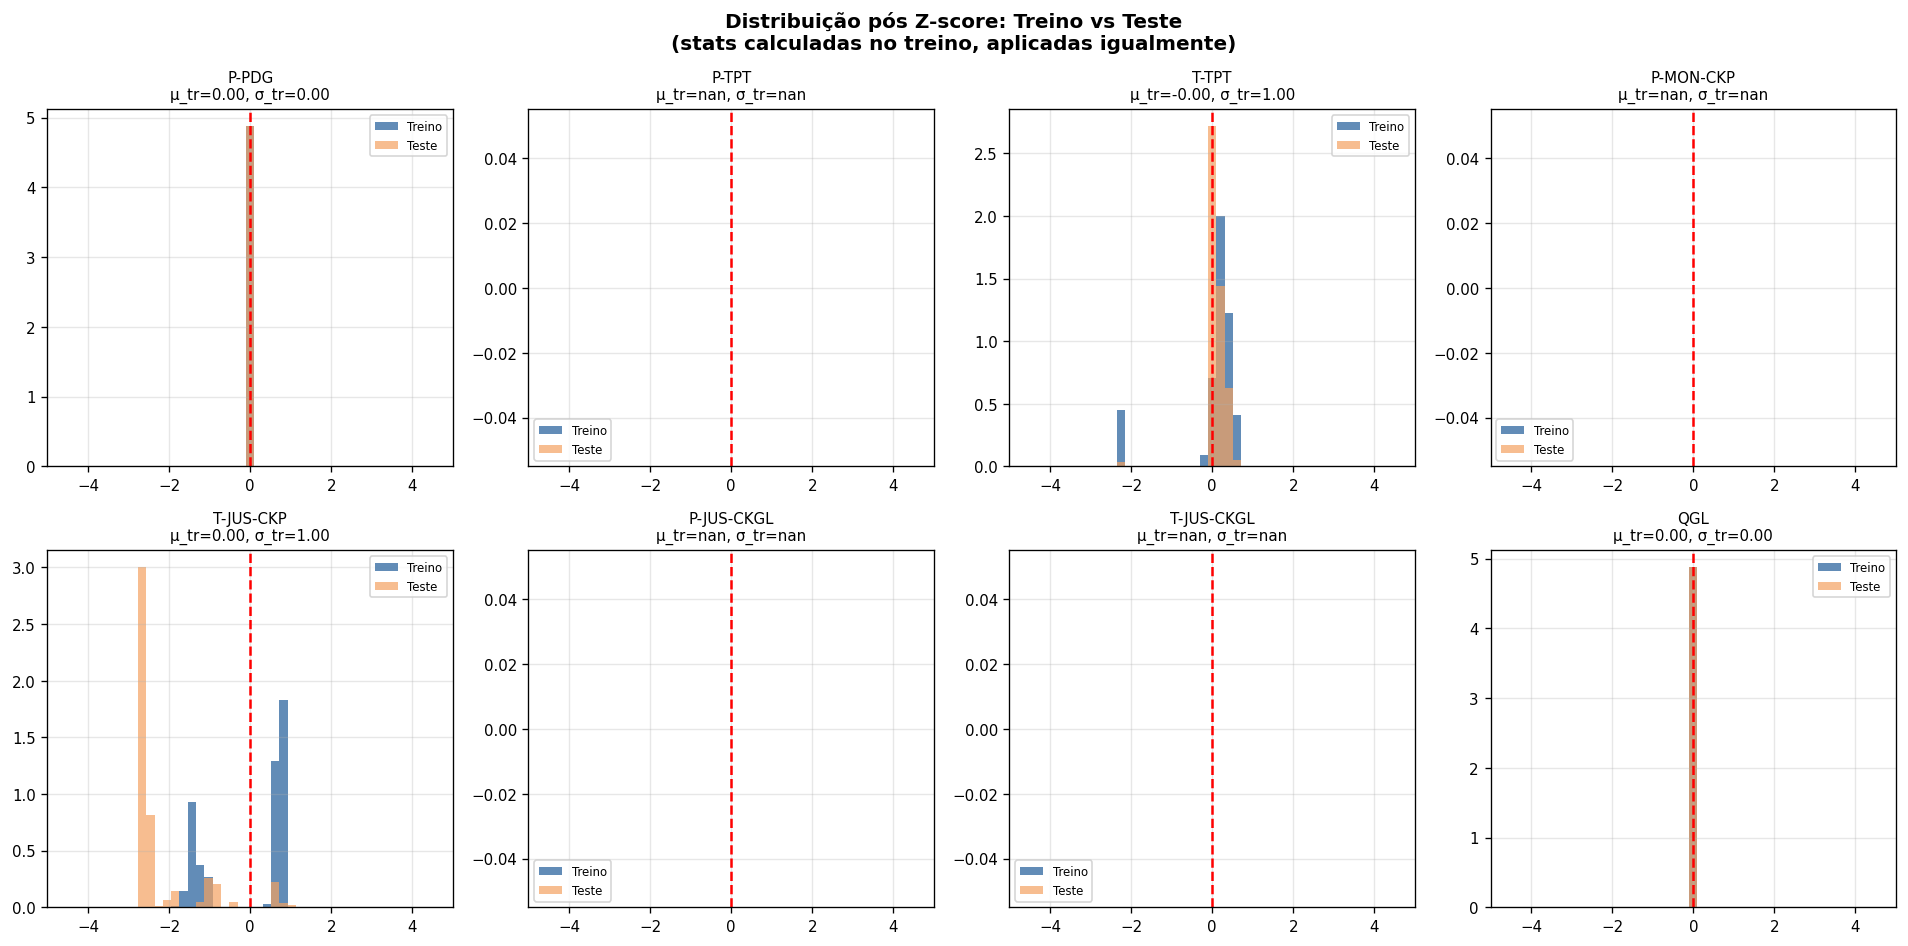


=== scaler_stats.json (primeiros 3 sensores) ===
{
  "P-PDG": {
    "mean": 0.0,
    "std": 1.0
  },
  "P-TPT": {
    "mean": NaN,
    "std": 1.0
  },
  "T-TPT": {
    "mean": 116.528269,
    "std": 4.302394
  }
}


In [12]:
# Demonstra o impacto do data leakage na normalização
def calcular_e_aplicar_z_score(df, feature_cols, split_ratio=0.70):
    """
    Divide temporalmente o DataFrame e aplica Z-score correto:
    stats calculadas APENAS no treino.
    Retorna (df_normalizado, scaler_stats)
    """
    n = len(df)
    n_treino = int(n * split_ratio)

    # Máscara de treino
    mask_treino = pd.Series([True] * n_treino + [False] * (n - n_treino), index=df.index)

    scaler_stats = {}
    df_norm = df.copy()

    for col in feature_cols:
        if col not in df.columns:
            continue
        # Calcula stats SOMENTE no treino
        train_vals = df.loc[mask_treino, col].dropna()
        mean_val = float(train_vals.mean())
        std_val  = float(train_vals.std())
        if pd.isna(std_val) or std_val == 0:
            std_val = 1.0

        scaler_stats[col] = {'mean': round(mean_val, 6), 'std': round(std_val, 6)}

        # Aplica a todo o dataset (treino + val + teste)
        df_norm[col] = (df[col] - mean_val) / std_val

    return df_norm, scaler_stats, mask_treino


# Aplica ao conjunto Silver
sensor_presentes = [c for c in SENSOR_COLUMNS if c in df_silver.columns]
df_silver_sorted = df_silver.sort_values('timestamp').reset_index(drop=True) \
    if 'timestamp' in df_silver.columns else df_silver.copy()

df_norm, stats_norm, mask_treino = calcular_e_aplicar_z_score(
    df_silver_sorted, sensor_presentes, split_ratio=0.70
)

# Visualiza: distribuição treino vs test antes/depois
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribuição pós Z-score: Treino vs Teste\n(stats calculadas no treino, aplicadas igualmente)', fontsize=12, fontweight='bold')

for ax, sensor in zip(axes.flatten(), sensor_presentes):
    col_norm = sensor
    dados_tr = df_norm.loc[mask_treino, col_norm].dropna()
    dados_te = df_norm.loc[~mask_treino, col_norm].dropna()

    bins = np.linspace(-4, 4, 40)
    ax.hist(dados_tr, bins=bins, alpha=0.7, color='#1F5C99', label='Treino', density=True)
    ax.hist(dados_te, bins=bins, alpha=0.7, color='#F4A261', label='Teste',  density=True)
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'{sensor}\nμ_tr={dados_tr.mean():.2f}, σ_tr={dados_tr.std():.2f}', fontsize=9)
    ax.set_xlim(-5, 5)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Exibe o scaler_stats (o que é salvo em scaler_stats.json)
import json
print('\n=== scaler_stats.json (primeiros 3 sensores) ===')
print(json.dumps({k: v for k, v in list(stats_norm.items())[:3]}, indent=2))

## Célula 11 — Feature Engineering: Rolling Statistics, Lags e Deltas

Features simples dos valores instantâneos capturam o estado atual,
mas eventos como slugging ou hidrato têm **padrões temporais** que só
aparecem ao olhar para uma janela de tempo.

### Features Criadas

| Tipo | Janelas/Passos | Quantidade | Descrição |
|------|---------------|------------|----------|
| **Rolling mean** | 5, 10, 30 | 24 | Tendência suavizada por janela |
| **Rolling std** | 5, 10, 30 | 24 | Volatilidade local (detecta slugging) |
| **Rolling min** | 5, 10, 30 | 24 | Piso local do sensor |
| **Rolling max** | 5, 10, 30 | 24 | Teto local do sensor |
| **Lag** | 1, 3, 5 | 24 | Valor em t-1, t-3, t-5 (memória temporal) |
| **Delta** | — | 8 | Taxa de variação: x(t) - x(t-1) |

Total: **8 sensores × (12 rolling + 3 lag + 1 delta) = 128 features** + 8 originais = **136 features**

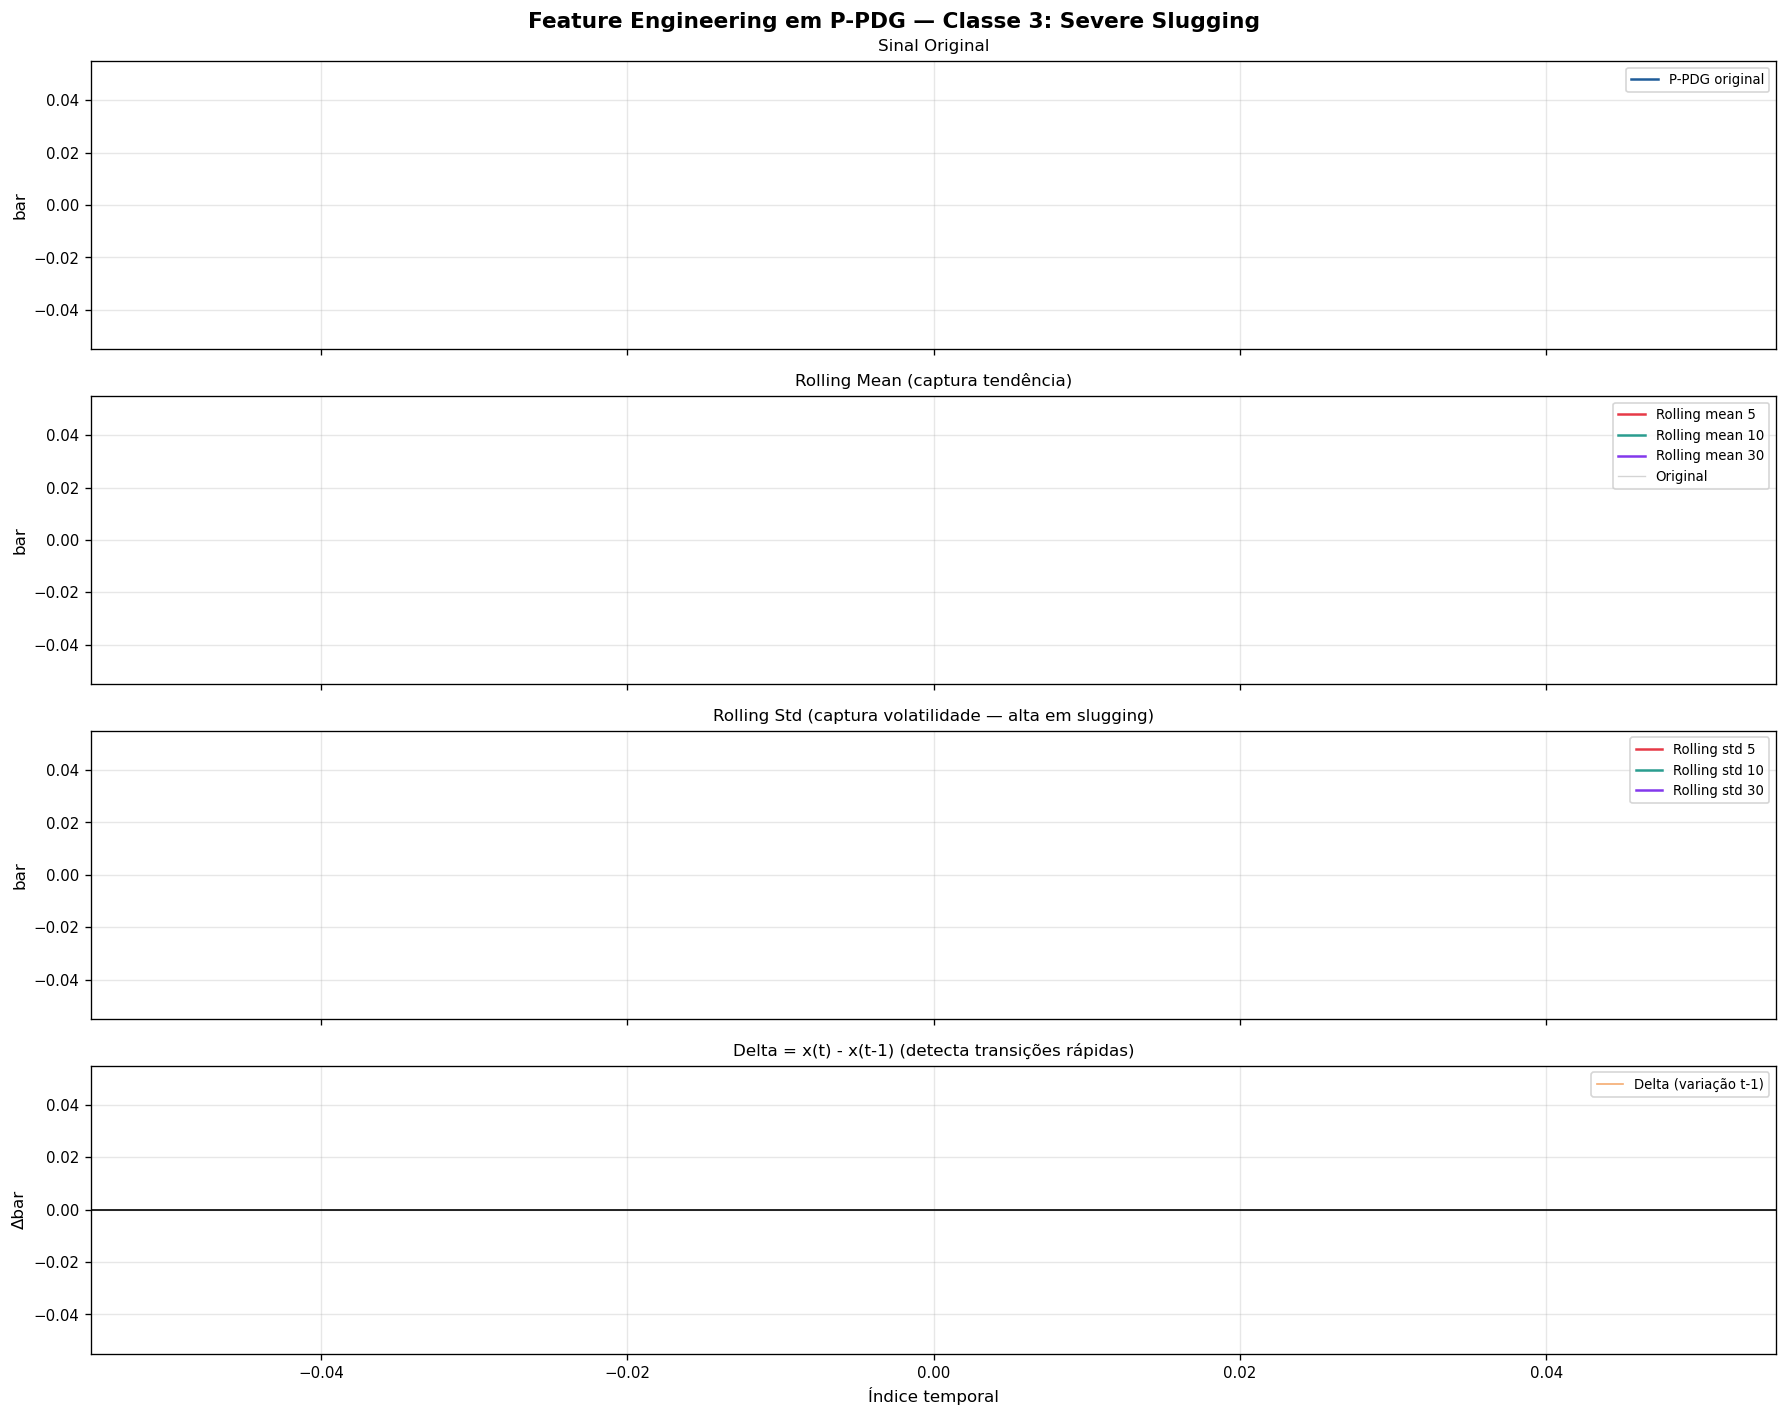

In [13]:
# Feature Engineering — demonstração em uma série temporal
ROLLING_WINDOWS = [5, 10, 30]
LAG_STEPS = [1, 3, 5]

def criar_features_temporal(df, sensor, partition_col='ID_Poco'):
    """
    Cria rolling stats, lags e delta para um sensor.
    Respeita a partição por poço para não misturar séries diferentes.
    """
    df = df.copy()
    safe = sensor.replace('-', '_')

    if partition_col in df.columns:
        grp = df.groupby(partition_col)[sensor]
    else:
        grp = df[sensor]

    # Rolling statistics
    for w in ROLLING_WINDOWS:
        df[f'{safe}_roll_mean_{w}'] = grp.transform(lambda s: s.rolling(w, min_periods=1).mean())
        df[f'{safe}_roll_std_{w}']  = grp.transform(lambda s: s.rolling(w, min_periods=1).std().fillna(0))
        df[f'{safe}_roll_min_{w}']  = grp.transform(lambda s: s.rolling(w, min_periods=1).min())
        df[f'{safe}_roll_max_{w}']  = grp.transform(lambda s: s.rolling(w, min_periods=1).max())

    # Lag features
    for lag in LAG_STEPS:
        df[f'{safe}_lag_{lag}'] = grp.transform(lambda s: s.shift(lag))

    # Delta (taxa de variação)
    df[f'{safe}_delta'] = grp.transform(lambda s: s.diff())

    return df


# Aplica para P-PDG como demonstração
df_demo_feat = df_silver.head(2000).copy()
df_demo_feat = criar_features_temporal(df_demo_feat, 'P-PDG')

# Visualiza o efeito das features em um trecho de Slugging (classe 3)
df_slug = df_silver[df_silver['class'] == 3].head(300).copy()
df_slug = criar_features_temporal(df_slug, 'P-PDG')

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Feature Engineering em P-PDG — Classe 3: Severe Slugging', fontsize=13, fontweight='bold')
x = np.arange(len(df_slug))

# Sinal original
axes[0].plot(x, df_slug['P-PDG'], color='#1F5C99', lw=1.5, label='P-PDG original')
axes[0].set_ylabel('bar')
axes[0].set_title('Sinal Original', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Rolling mean — suaviza oscilações
for w, cor in [(5, '#E63946'), (10, '#2A9D8F'), (30, '#8338EC')]:
    axes[1].plot(x, df_slug[f'P_PDG_roll_mean_{w}'], lw=1.5, label=f'Rolling mean {w}', color=cor)
axes[1].plot(x, df_slug['P-PDG'], color='#aaa', lw=0.8, alpha=0.5, label='Original')
axes[1].set_ylabel('bar')
axes[1].set_title('Rolling Mean (captura tendência)', fontsize=10)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)

# Rolling std — detecta volatilidade (útil para slugging)
for w, cor in [(5, '#E63946'), (10, '#2A9D8F'), (30, '#8338EC')]:
    axes[2].plot(x, df_slug[f'P_PDG_roll_std_{w}'], lw=1.5, label=f'Rolling std {w}', color=cor)
axes[2].set_ylabel('bar')
axes[2].set_title('Rolling Std (captura volatilidade — alta em slugging)', fontsize=10)
axes[2].legend(fontsize=8, loc='upper right')
axes[2].grid(alpha=0.3)

# Delta — taxa de variação
axes[3].plot(x, df_slug['P_PDG_delta'], color='#F4A261', lw=1, label='Delta (variação t-1)', alpha=0.9)
axes[3].axhline(0, color='black', lw=1)
axes[3].set_ylabel('Δbar')
axes[3].set_title('Delta = x(t) - x(t-1) (detecta transições rápidas)', fontsize=10)
axes[3].legend(fontsize=8)
axes[3].grid(alpha=0.3)
axes[3].set_xlabel('Índice temporal')

plt.tight_layout()
plt.show()

## Célula 12 — Camada GOLD: Splits Temporais e Dataset ML-Ready

A camada Gold é o **dataset final** para treinamento. A divisão é **temporal**,
não aleatória — respeitando a ordem cronológica dos dados:

```
|←────── 70% Treino ────────→|←── 15% Val ──→|←── 15% Teste ──→|
t_0                        t_70%           t_85%              t_final
```

**Por que temporal e não aleatória?**
- Simula condições reais de produção: o modelo treina no passado e prediz o futuro
- Evita que eventos futuros contaminem o treino (outra forma de data leakage)
- Mantém a autocorrelação temporal — séries vizinhas são correlacionadas

Dados Gold reais: train=50,000 val=10,000 test=10,000


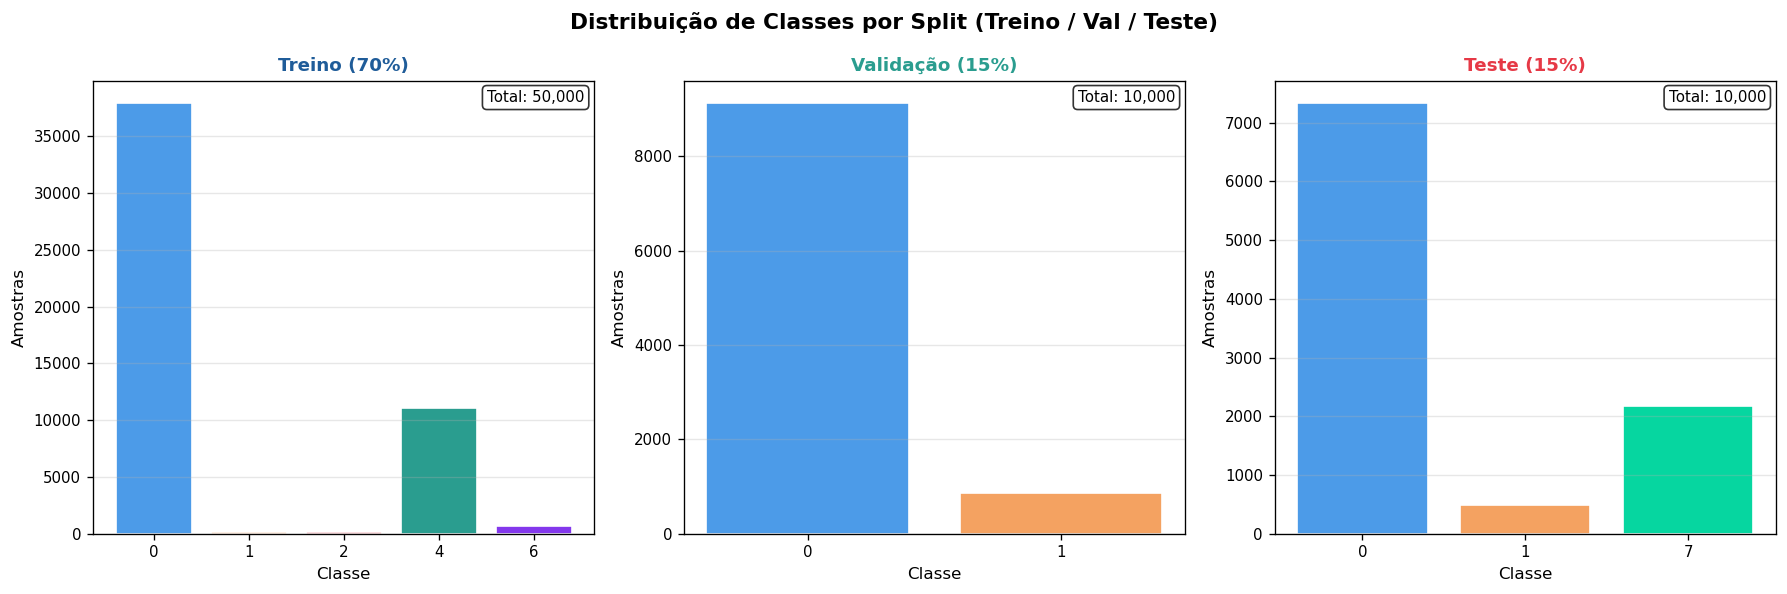


=== Proporção de cada classe por split ===


,Treino,Val,Teste
Cls 0: Normal,75.94,91.43,73.43
Cls 1: Abrupt Increase of B,0.36,8.57,4.88
Cls 2: Spurious Closure of,0.27,NaN,NaN
Cls 4: Flow Instability,22.08,NaN,NaN
Cls 6: Quick Restriction in,1.35,NaN,NaN
Cls 7: Scaling in PCK,NaN,NaN,21.69


In [14]:
# Demonstra o split temporal 70/15/15
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Carrega gold real ou usa silver normalizado
if USE_REAL_DATA:
    try:
        df_train = pd.read_parquet(GOLD_DIR / 'train.parquet')
        df_val   = pd.read_parquet(GOLD_DIR / 'val.parquet')
        df_test  = pd.read_parquet(GOLD_DIR / 'test.parquet')
        # Amostra para o notebook
        df_train = df_train.sample(min(50000, len(df_train)), random_state=42)
        df_val   = df_val.sample(min(10000, len(df_val)), random_state=42)
        df_test  = df_test.sample(min(10000, len(df_test)), random_state=42)
        print(f'Dados Gold reais: train={len(df_train):,} val={len(df_val):,} test={len(df_test):,}')
        GOLD_LOADED = True
    except Exception as e:
        print(f'Gold nao disponivel: {e}\nUsando Silver normalizado.')
        GOLD_LOADED = False
else:
    GOLD_LOADED = False

# Fallback: split manual do Silver normalizado
if not GOLD_LOADED:
    df_sorted = df_silver_sorted.copy()
    n = len(df_sorted)
    i70 = int(n * TRAIN_RATIO)
    i85 = int(n * (TRAIN_RATIO + VAL_RATIO))
    df_train = df_sorted.iloc[:i70]
    df_val   = df_sorted.iloc[i70:i85]
    df_test  = df_sorted.iloc[i85:]
    print(f'Split temporal: train={len(df_train):,} val={len(df_val):,} test={len(df_test):,}')

# Visualiza os splits
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribuição de Classes por Split (Treino / Val / Teste)', fontsize=13, fontweight='bold')

for ax, (df_split, titulo, cor) in zip(axes, [
    (df_train, f'Treino ({TRAIN_RATIO*100:.0f}%)', '#1F5C99'),
    (df_val,   f'Validação ({VAL_RATIO*100:.0f}%)', '#2A9D8F'),
    (df_test,  f'Teste ({TEST_RATIO*100:.0f}%)', '#E63946'),
]):
    if 'class' not in df_split.columns:
        ax.text(0.5, 0.5, 'Sem coluna class', ha='center', va='center', transform=ax.transAxes)
        continue
    dist_split = df_split['class'].value_counts().sort_index()
    cores_cls = [CLASS_COLORS.get(int(c), '#aaa') for c in dist_split.index]
    ax.bar([str(int(c)) for c in dist_split.index], dist_split.values,
           color=cores_cls, edgecolor='white')
    ax.set_title(titulo, fontsize=11, color=cor, fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Amostras')
    ax.grid(axis='y', alpha=0.3)
    total = len(df_split)
    ax.text(0.98, 0.98, f'Total: {total:,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Tabela de proporções por split
print('\n=== Proporção de cada classe por split ===')
dfs = {'Treino': df_train, 'Val': df_val, 'Teste': df_test}
if all('class' in df.columns for df in dfs.values()):
    tabela = {}
    for split_name, df_split in dfs.items():
        tabela[split_name] = (df_split['class'].value_counts(normalize=True) * 100).round(2)
    df_tabela = pd.DataFrame(tabela).sort_index()
    df_tabela.index = [f'Cls {int(i)}: {EVENT_LABELS.get(int(i), "?")[:20]}' for i in df_tabela.index]
    display(df_tabela)

## Célula 13 — Dados de Treinamento e Estratégia de ML

### Modelos treinados no projeto

| Modelo | Script | Estratégia de desbalanceamento | Features |
|--------|--------|-------------------------------|----------|
| **Random Forest** | `train_rf_baseline.py` | `class_weight='balanced'` | 136 (rolling + lag + delta) |
| **XGBoost** | `train_xgb_baseline.py` | `sample_weight` inverso da freq | 136 |
| **LightGBM** | `train_lgb_baseline.py` | `class_weight='balanced'` | 136 |

### Como o `class_weight='balanced'` funciona?

Para cada classe `k`, o peso é calculado como:
```
w_k = n_amostras / (n_classes × n_amostras_da_classe_k)
```
Classes raras recebem peso maior, forçando o modelo a prestar mais atenção a elas.

In [15]:
# Simula o treinamento de um Random Forest simples com os dados disponíveis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Seleciona features disponíveis (sensores ou features _norm do Gold)
feat_cols = [c for c in df_train.columns if c.endswith('_norm')]
if not feat_cols:
    feat_cols = [c for c in SENSOR_COLUMNS if c in df_train.columns]
    print(f'Usando {len(feat_cols)} sensores brutos (Gold nao disponivel)')
else:
    print(f'Usando {len(feat_cols)} features normalizadas do Gold')

def preparar_split(df, feat_cols, target_col='class'):
    """Prepara arrays X, y para sklearn, removendo NaN."""
    mask = df[feat_cols + [target_col]].notna().all(axis=1)
    Xd = df.loc[mask, feat_cols].values.astype('float32')
    yd = df.loc[mask, target_col].values.astype('int32')
    # Substitui inf por 0
    Xd = np.where(np.isfinite(Xd), Xd, 0.0).astype('float32')
    return Xd, yd

if 'class' in df_train.columns and feat_cols:
    X_train, y_train = preparar_split(df_train, feat_cols)
    X_val,   y_val   = preparar_split(df_val,   feat_cols)
    X_test,  y_test  = preparar_split(df_test,  feat_cols)

    print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
    print(f'Classes no treino: {sorted(np.unique(y_train).tolist())}')

    # Treina RF com 50 árvores (rápido para demonstração)
    print('\nTreinando Random Forest (50 arvores, class_weight=balanced)...')
    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)

    y_pred_test = rf.predict(X_test)
    classes_presentes = sorted(np.unique(np.concatenate([y_train, y_test])))

    print('\n=== Classification Report — Conjunto de Teste ===')
    print(classification_report(
        y_test, y_pred_test,
        labels=classes_presentes,
        target_names=[EVENT_LABELS.get(c, f'Cls{c}') for c in classes_presentes],
        zero_division=0,
    ))
    f1_w = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    f1_m = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    print(f'F1 Weighted: {f1_w:.4f}  |  F1 Macro: {f1_m:.4f}')
else:
    print('Coluna "class" nao encontrada ou sem features. Pulando treinamento.')

Usando 136 features normalizadas do Gold
X_train: (50000, 136)  X_val: (10000, 136)  X_test: (10000, 136)
Classes no treino: [0, 1, 2, 4, 6]

Treinando Random Forest (50 arvores, class_weight=balanced)...

=== Classification Report — Conjunto de Teste ===
                          precision    recall  f1-score   support

                  Normal       0.96      1.00      0.98      7343
  Abrupt Increase of BSW       0.00      0.00      0.00       488
Spurious Closure of DHSV       0.00      0.00      0.00         0
        Flow Instability       0.00      0.00      0.00         0
Quick Restriction in PCK       0.00      0.00      0.00         0
          Scaling in PCK       0.00      0.00      0.00      2169

                accuracy                           0.73     10000
               macro avg       0.16      0.17      0.16     10000
            weighted avg       0.70      0.73      0.72     10000

F1 Weighted: 0.7176  |  F1 Macro: 0.2443


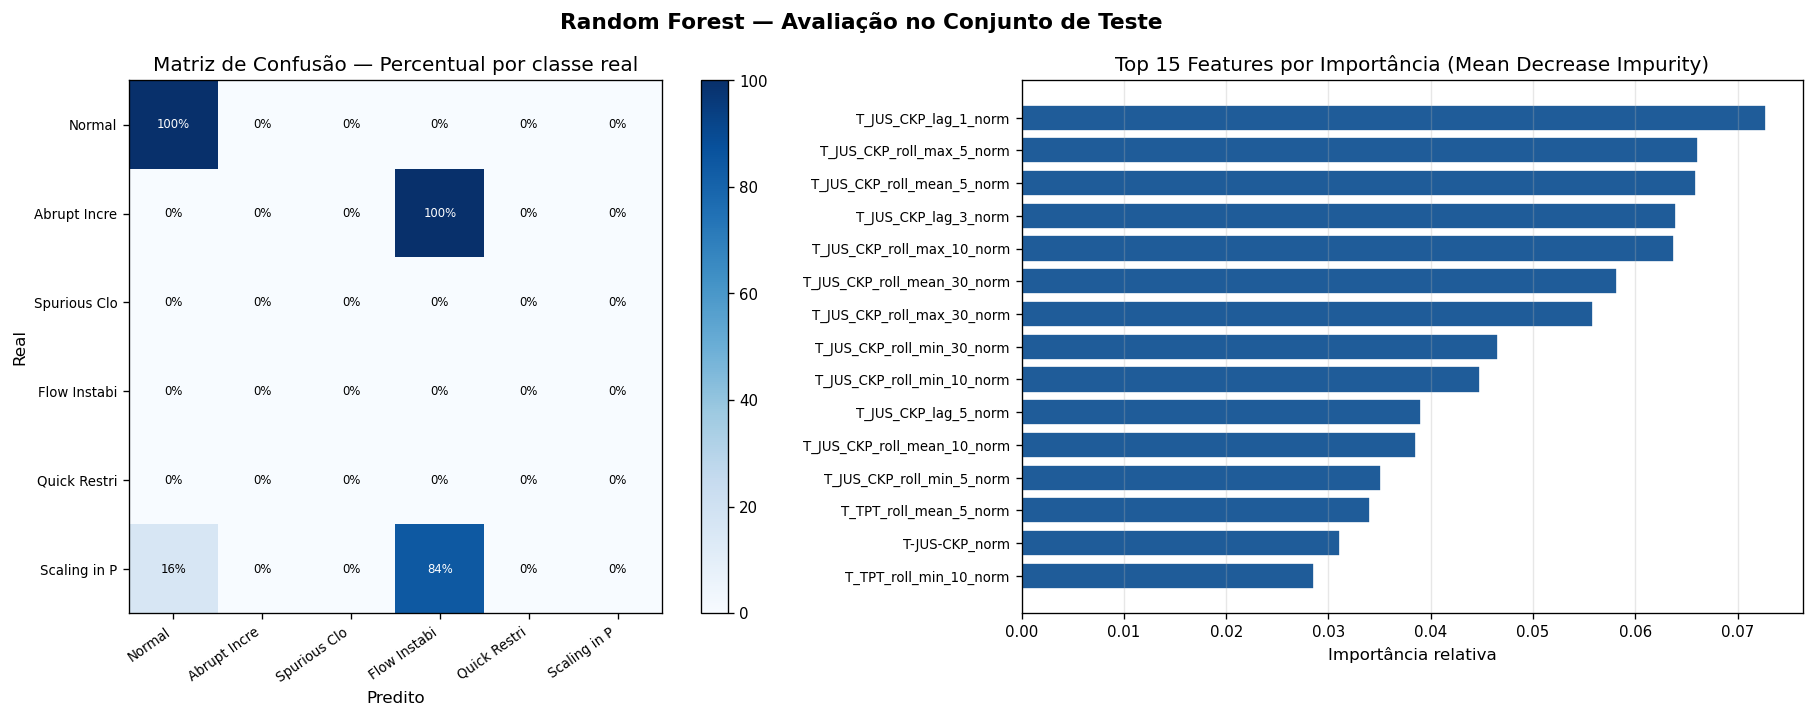

In [16]:
# Visualiza: Matriz de Confusão + Importância de Features
if 'rf' in dir() and 'y_pred_test' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Random Forest — Avaliação no Conjunto de Teste', fontsize=13, fontweight='bold')

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred_test, labels=classes_presentes)
    cm_pct = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    labels_cm = [EVENT_LABELS.get(c, f'Cls{c}')[:12] for c in classes_presentes]
    im = axes[0].imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    axes[0].set_xticks(range(len(labels_cm)))
    axes[0].set_yticks(range(len(labels_cm)))
    axes[0].set_xticklabels(labels_cm, rotation=35, ha='right', fontsize=8)
    axes[0].set_yticklabels(labels_cm, fontsize=8)
    axes[0].set_xlabel('Predito')
    axes[0].set_ylabel('Real')
    axes[0].set_title('Matriz de Confusão — Percentual por classe real')
    thresh = 50
    for i in range(len(labels_cm)):
        for j in range(len(labels_cm)):
            axes[0].text(j, i, f'{cm_pct[i,j]:.0f}%', ha='center', va='center',
                         color='white' if cm_pct[i,j] > thresh else 'black', fontsize=7)
    plt.colorbar(im, ax=axes[0])

    # Importância de features (top 15)
    importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
    top15 = importances.head(15)
    axes[1].barh(top15.index[::-1], top15.values[::-1], color='#1F5C99', edgecolor='white')
    axes[1].set_title('Top 15 Features por Importância (Mean Decrease Impurity)')
    axes[1].set_xlabel('Importância relativa')
    axes[1].tick_params(axis='y', labelsize=8)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Modelo nao treinado — célula anterior falhou ou sem dados.')

## Célula 14 — Resumo da Metodologia

### Pipeline Completo RAW → GOLD

```
GitHub (petrobras/3W)
    │
    ▼ ingestao_unificada.py — download via API, filtro por poço e classe
RAW  (data/raw/)           — Parquets originais, sem modificação
    │
    ▼ run_bronze()          — tipagem, schema, metadados
BRONZE (data/bronze/)      — float64, int8, datetime, bronze_at
    │
    ▼ run_silver()          — ranges físicos, forward fill, deduplicação
SILVER (data/silver/)      — dados limpos e confiáveis, silver_at
    │
    ▼ run_gold()            — rolling/lag/delta + Z-score (fit no treino)
GOLD (data/gold/)          — train.parquet / val.parquet / test.parquet
                             scaler_stats.json
    │
    ▼ train_*.py            — RF / XGBoost / LightGBM com class_weight=balanced
models/                    — *.joblib + reports + confusion matrices
```

### Decisões-Chave da Metodologia

| Decisão | Alternativa considerada | Justificativa |
|---------|------------------------|---------------|
| Z-score (fit no treino) | MinMax global | Evita data leakage temporal |
| Split temporal 70/15/15 | KFold aleatório | Simula condições reais de produção |
| Forward fill por poço | Interpolação linear | Fisicamente realista para falhas de sensor |
| `class_weight='balanced'` | Oversampling/SMOTE | Mais simples; evita criar dados sintéticos |
| Rolling windows [5,10,30] | FFT / wavelet | Interpretável e eficiente em memória |
| Classe 9 excluída do treino | Incluir como classe | Evento indefinido = ruído sem rótulo preciso |